# Neural Networks deep learning model Tutorial

Hand writing numbers recognetion

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.getcwd() # Current Working directory

'/content'

In [3]:
# Create Working Directory if necessary

PROJECT_ROOT_DIR = "/content/drive/MyDrive/Colab Notebooks/Cours MAE"

os.makedirs(PROJECT_ROOT_DIR, exist_ok=True)

# Change the current working directory

os.chdir(PROJECT_ROOT_DIR)

os.getcwd() # Current Working directory

'/content/drive/MyDrive/Colab Notebooks/Cours MAE'

In [4]:
# import tensorflow package

import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


In [5]:
# import other Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Load the data set

In [6]:
# MNIST data set containing 60 000 + 10 000 hand writing pictures (np array 28x28)
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
len(y_train)

60000

In [9]:
x_test.shape

(10000, 28, 28)

In [10]:
len(y_test)

10000

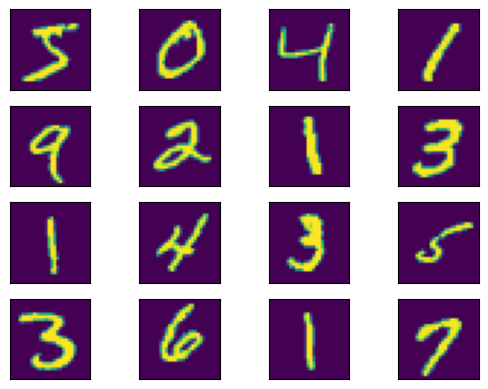

In [11]:
# View the content of x_train vs. y_train

path_images = './images/'

fig, axs = plt.subplots(4, 4)

for n in range(0,16):
    i = n // 4
    j = n % 4
    axs[i, j].imshow(x_train[n])
    axs[i, j].set_xticks([])
    axs[i, j].set_yticks([])

#plt.show()
plt.savefig(path_images + 'MNIST_digits_1.pdf')

In [12]:
y_train[0:16].reshape(4,4)

array([[5, 0, 4, 1],
       [9, 2, 1, 3],
       [1, 4, 3, 5],
       [3, 6, 1, 7]], dtype=uint8)

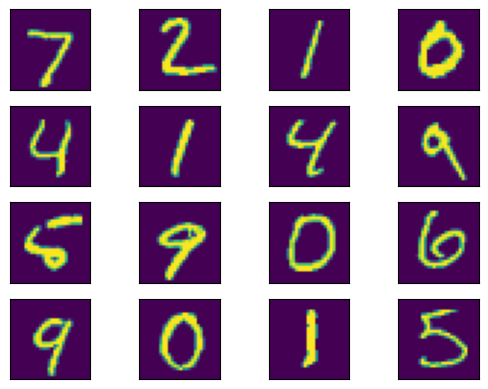

In [13]:
# View the content of x_test vs. y_test

fig, axs = plt.subplots(4, 4)

for n in range(0,16):
    i = n // 4
    j = n % 4
    axs[i, j].imshow(x_test[n])
    axs[i, j].set_xticks([])
    axs[i, j].set_yticks([])

#plt.show()
plt.savefig(path_images + 'MNIST_digits_2.pdf')

In [14]:
y_test[0:16].reshape(4,4)

array([[7, 2, 1, 0],
       [4, 1, 4, 9],
       [5, 9, 0, 6],
       [9, 0, 1, 5]], dtype=uint8)

In [15]:
# Preprocess the data before training

x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [16]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [17]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

## Build the Artificial Neural Networks model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from tensorflow.keras import activations

In [19]:
# model specification
# input 28x28 np array reshaped to 784 vector
# 1 hidden layer of 128 cells
# 10 output cells : 0, 1, 2, ..., 9
# output values = probability of each number

'''
model = Sequential()
model.add(Dense(128, input_dim=784, activation='relu'))
model.add(Dense(10, activation='softmax'))
'''

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model = Sequential()
model.add(Dense(128, input_shape=(784,), activation='relu'))
model.add(Dense(10, activation='softmax'))

In [23]:
# Compile the model

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [24]:
# Train (fit) the model with train data

history = model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8851 - loss: 0.4095
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9627 - loss: 0.1270
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9758 - loss: 0.0819
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9799 - loss: 0.0672
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9837 - loss: 0.0545
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9871 - loss: 0.0434
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9881 - loss: 0.0405
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9909 - loss: 0.0334
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9922 - loss: 0.0285
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9923 - loss: 0.0263


In [25]:
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


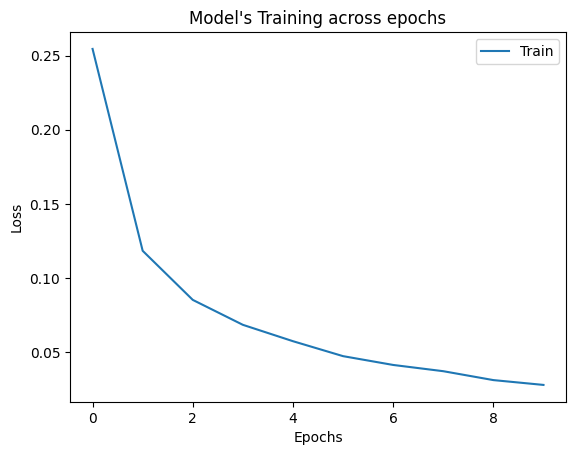

In [26]:
# Plot loss curve

plt.plot(history.history['loss'])
plt.title("Model's Training across epochs")
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train'], loc='upper right')
#plt.show()
plt.savefig(path_images + 'MNIST_loss.pdf')

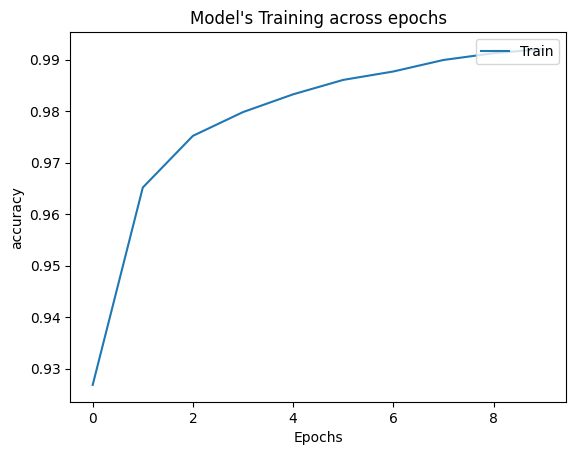

In [27]:
# Plot accuracy curve

plt.plot(history.history['accuracy'])
plt.title("Model's Training across epochs")
plt.ylabel('accuracy')
plt.xlabel('Epochs')
plt.legend(['Train'], loc='upper right')
#plt.show()
plt.savefig(path_images + 'MNIST_accuracy.pdf')

In [28]:
# Evaluate the trained model

model.evaluate(x_test,  y_test, verbose=2)

313/313 - 1s - 2ms/step - accuracy: 0.9776 - loss: 0.0900


[0.08998577296733856, 0.9775999784469604]

## Use the trained model to predict

In [29]:
# Use the trained model to predict the result

pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [30]:
pred[0:2]

array([[3.7861971e-11, 5.8469451e-14, 3.4570130e-10, 1.6426585e-06,
        2.3997223e-15, 1.7907597e-11, 3.0646827e-22, 9.9999827e-01,
        1.5189064e-10, 7.0859234e-09],
       [3.0840326e-15, 5.8808496e-09, 9.9999827e-01, 1.0848700e-06,
        1.0037574e-18, 6.0802479e-09, 1.3725414e-11, 3.5051349e-22,
        5.4028385e-07, 4.0010569e-19]], dtype=float32)

In [32]:
y_pred = np.ones(len(x_test))
y_pred[:] = np.nan

In [38]:
# Converting the pred (number probability to numbuer)

for i in range(0, len(x_test)):
    for j in range (0,10):
        if (pred[i,j] > 0.5):
            y_pred[i] = j

In [39]:
df_PredvsTest = pd.DataFrame()

In [40]:
df_PredvsTest['Pred'] = y_pred
df_PredvsTest['Test'] = y_test

In [41]:
df_PredvsTest.head()

,Pred,Test
0,7.0,7
1,2.0,2
2,1.0,1
3,0.0,0
4,4.0,4


In [42]:
# Drop the missing values
df_PredvsTest.dropna(inplace=True)

In [43]:
df_PredvsTest.shape

(9988, 2)

In [44]:
df_PredvsTest.head()

,Pred,Test
0,7.0,7
1,2.0,2
2,1.0,1
3,0.0,0
4,4.0,4


In [45]:
df_PredvsTest['Pred'] = df_PredvsTest['Pred'].astype(int)

In [46]:
df_PredvsTest.head()

,Pred,Test
0,7,7
1,2,2
2,1,1
3,0,0
4,4,4


In [47]:
# Compute the confusion matrix

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.colors as clrs

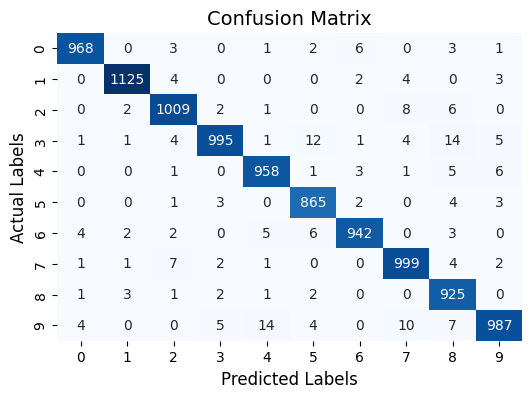

In [48]:
# Define the confusion matrix
confusion_matrix_data = confusion_matrix(df_PredvsTest.Pred, df_PredvsTest.Test)

# Plot the data
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(confusion_matrix_data, fmt="d",
                cmap='Blues', cbar=False, annot=True, ax=ax)

# Set the axes labels and the title
ax.set_xlabel('Predicted Labels', fontsize=12)
ax.set_ylabel('Actual Labels', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14)

plt.show()

In [49]:
# Libraries for evaluating the model
from sklearn.metrics import classification_report

# Classification report
classification_report_data = classification_report(df_PredvsTest.Pred, df_PredvsTest.Test)

# Print the classification report
print(classification_report_data)

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       984
           1       0.99      0.99      0.99      1138
           2       0.98      0.98      0.98      1028
           3       0.99      0.96      0.97      1038
           4       0.98      0.98      0.98       975
           5       0.97      0.99      0.98       878
           6       0.99      0.98      0.98       964
           7       0.97      0.98      0.98      1017
           8       0.95      0.99      0.97       935
           9       0.98      0.96      0.97      1031

    accuracy                           0.98      9988
   macro avg       0.98      0.98      0.98      9988
weighted avg       0.98      0.98      0.98      9988



## Save and Load the model trained

In [50]:
# Save the topology of the ANN model to a JSON file

model_json = model.to_json()

path = "./models/"
os.makedirs(path, exist_ok=True)

with open(path + "model_MNIST.json", "w") as json_file:
    json_file.write(model_json)

# Save the weights to a HDF5 file

# model.save_weights(path+"model_MNIST.h5")

model.save_weights(path+"model_MNIST.weights.h5")

print("Saved model to disk")

Saved model to disk


In [51]:
# Load the JSON file and create model

from keras.models import model_from_json

path = "./models/"

json_file = open(path + "model_MNIST.json", 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)

# Load the saved weights into loaded_model
loaded_model.load_weights(path+"model_MNIST.weights.h5")

print("Loaded model from disk")

Loaded model from disk
